# Improve Training

In [1]:
## Package Import & Path Setting

from pathlib import Path
import pandas as pd
from pandas import DataFrame as df
import numpy as np
import matplotlib.pyplot as plt

# data split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

# preprocessing & structure
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# pytorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# other imports
from tqdm.auto import tqdm
from sklearn.dummy import DummyClassifier

In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
else:
    print("Using CPU version")

PyTorch version: 2.9.1+cpu
CUDA available: False
Using CPU version


In [ ]:
# helper functions

# baseline model
class LogisticClass(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(1)

 
# training class
class Trainer():
    def __init__(self, model, optimizer, loss_fn, metrics, device=None):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metrics = metrics
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.hist = {"loss": [], "val_loss": []}
        for name in self.metrics.keys():
            self.hist[name] = []        

    def train(self, train_data, val_data, batch_size, epochs):
        X_tr_np, y_tr_np = train_data
        X_val_np, y_val_np = val_data
        
        X_tr = torch.tensor(X_tr_np, dtype=torch.float32)
        y_tr = torch.tensor(y_tr_np, dtype=torch.float32)
        X_val = torch.tensor(X_val_np, dtype=torch.float32)
        y_val = torch.tensor(y_val_np, dtype=torch.float32)

        if y_tr.ndim == 1:
            y_tr = y_tr.view(-1, 1)
        if y_val.ndim == 1:
            y_val = y_val.view(-1, 1)

        train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)             

        # for epoch in range(epochs):
        for epoch in tqdm(range(epochs), desc="Training", leave=False):
            self.model.train()
            total_loss = 0
            total_n = 0
            for x, y in train_loader:
                x = x.to(self.device)
                y = y.to(self.device)
                self.optimizer.zero_grad()
                logits = self.model(x).squeeze()
                loss = self.loss_fn(logits, y.squeeze())
                actual_bs = x.size(0)
                total_loss += loss.item() * actual_bs
                total_n += actual_bs
                loss.backward()
                self.optimizer.step()
            self.hist['loss'].append(total_loss / max(total_n, 1))            
            # validation
            self.model.eval()
            val_total_loss = 0
            val_total_n = 0            
            probs_list = []
            with torch.no_grad():
                for x, y in val_loader:
                    x = x.to(self.device)
                    y = y.to(self.device)
                    logits = self.model(x).squeeze()
                    loss = self.loss_fn(logits, y.squeeze())
                    actual_bs = x.size(0)
                    val_total_loss += loss.item() * actual_bs
                    val_total_n += actual_bs
                    p = torch.sigmoid(logits).detach().cpu().numpy()
                    probs_list.append(p)
            
            self.hist["val_loss"].append(val_total_loss / max(val_total_n, 1))
            probs = np.concatenate(probs_list, axis=0)
            probs_1d = probs.reshape(-1)

            for name, spec in self.metrics.items():
                if spec["input_type"] == "prob":
                    self.hist[name].append(spec["func"](y_val, probs_1d))
                elif spec["input_type"] == "label":
                    pred = (probs_1d >= 0.5).astype(int)
                    self.hist[name].append(spec["func"](y_val, pred))
                else:
                    raise ValueError(f"Unknown input_type for metric '{name}': {spec['input_type']}")
        return self.hist

# cv train
## skf
# cv train
## skf

def perform_cv_baseline(X, y, skf, preprocess_func, device, batch_size=64, epochs=5, lr=1e-2, weight_decay=0.0):
    loss_fn = nn.BCEWithLogitsLoss()
    metrics = {'acc': {'input_type': 'label', 'func': accuracy_score},
               'auc': {'input_type': 'prob', 'func': roc_auc_score}}
    
    acc_scores = []
    auc_scores = []
    dummy_acc_scores = []
    dummy_auc_scores = []
    oof_probs = []
    oof_y_val = []
    oof_dummy_probs = []
    
    pbar = tqdm(skf.split(X, y), total=skf.get_n_splits(), desc="CV folds")
    
    for fold, (tr_idx, val_idx) in enumerate(pbar, start=1):
        X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        preprocess = preprocess_func()
        X_tr_np = preprocess.fit_transform(X_tr_raw)
        X_val_np = preprocess.transform(X_val_raw)
        train_data = X_tr_np, y_tr.to_numpy()
        val_data = X_val_np, y_val.to_numpy()
        model = LogisticClass(X_tr_np.shape[1]).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        trainer = Trainer(model, optimizer, loss_fn, metrics, device=device)
        hist = trainer.train(train_data, val_data, batch_size, epochs)
        with torch.no_grad():
            X_val = torch.tensor(X_val_np, dtype=torch.float32).to(device)
            logits = trainer.model(X_val)
            p = torch.sigmoid(logits).cpu().numpy()
        oof_probs.append(p)
        oof_y_val.append(y_val)
        pred = (p >= 0.5).astype(int).squeeze()
        auc_score = roc_auc_score(y_val, p)
        acc_score = accuracy_score(y_val, pred)
        acc_scores.append(acc_score)
        auc_scores.append(auc_score)
        # dummy model
        dummy_model = DummyClassifier(strategy='most_frequent', random_state=37)
        dummy_model.fit(X_tr_np, y_tr.to_numpy())
        dummy_pred = np.asarray(dummy_model.predict(X_val_np), dtype=int).ravel()
        dummy_prob = np.asarray(dummy_model.predict_proba(X_val_np)[:, 1], dtype=float).ravel()
        oof_dummy_probs.append(dummy_prob)
        dummy_acc_score = accuracy_score(y_val, dummy_pred)
        dummy_acc_scores.append(dummy_acc_score)
        dummy_auc_score = roc_auc_score(y_val, dummy_prob)
        dummy_auc_scores.append(dummy_auc_score)
        tqdm.write(f"Fold {fold} auc score (baseline / dummy): {auc_score:.4f} / {dummy_auc_score:.4f}, acc score: {acc_score:.4f} / {dummy_acc_score:.4f}")
        print(f"Baseline Model AUC/ACC Mean: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f} / {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    
    print(f"Dummy Model AUC/ACC Mean: {np.mean(dummy_auc_scores):.4f} ± {np.std(dummy_auc_scores):.4f} / {np.mean(dummy_acc_scores):.4f} ± {np.std(dummy_acc_scores):.4f}")
    print(f'Baseline Model AUC/ACC Lift: {(np.mean(auc_scores) - np.mean(dummy_auc_scores)):.4f} / {(np.mean(acc_scores) - np.mean(dummy_acc_scores)):.4f}')
    plt.figure()
    oof_probs = np.concatenate(oof_probs)
    oof_y_val = np.concatenate(oof_y_val)
    auc = roc_auc_score(oof_y_val, oof_probs)
    fpr, tpr, thr = roc_curve(oof_y_val, oof_probs)
    plt.plot(fpr, tpr, label=f'Baseline (AUC={auc:.4f})')
    oof_dummy_probs = np.concatenate(oof_dummy_probs)
    dummy_auc = roc_auc_score(oof_y_val, oof_dummy_probs)
    fpr, tpr, thr = roc_curve(oof_y_val, oof_dummy_probs)
    plt.plot(fpr, tpr, label=f'Dummy (AUC={dummy_auc:.4f})')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"OOF ROC Curve")
    plt.legend()
    plt.show()    
    return acc_scores, auc_scores, dummy_acc_scores, dummy_auc_scores, oof_probs, oof_y_val, oof_dummy_probs


# hyperparameter tuning
def cv_eval_fn(params):
    lr = params['lr']
    weight_decay = params['weight_decay']
    batch_size = params['batch_size']
    epochs = params['epochs']
    loss_fn = nn.BCEWithLogitsLoss()

    metrics = {'acc':{'input_type':'label', 'func':accuracy_score},
            'auc':{'input_type':'prob', 'func':roc_auc_score}
            }
    acc_scores = []
    auc_scores = []

    pbar = tqdm(skf.split(X, y), total=skf.get_n_splits(), desc="CV folds")

    for fold, (tr_idx, val_idx) in enumerate(pbar, start=1):
        X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        preprocess = create_new_preprocess()
        X_tr_np = preprocess.fit_transform(X_tr_raw)
        X_val_np = preprocess.transform(X_val_raw)
        train_data = X_tr_np, y_tr.to_numpy()
        val_data = X_val_np, y_val.to_numpy()
        model = LogisticClass(X_tr_np.shape[1]).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        trainer = Trainer(model, optimizer, loss_fn, metrics, device=DEVICE)
        hist = trainer.train(train_data, val_data, batch_size, epochs)
        with torch.no_grad():
            X_val = torch.tensor(X_val_np, dtype=torch.float32).to(DEVICE)
            logits = trainer.model(X_val)
            p = torch.sigmoid(logits).cpu().numpy()
   
        pred = (p >= 0.5).astype(int).squeeze()
        auc_score = roc_auc_score(y_val, p)
        acc_score = accuracy_score(y_val, pred)
        acc_scores.append(acc_score)
        auc_scores.append(auc_score)    

    mean_score = np.mean(auc_scores)
    std_score = np.std(auc_scores) 
    # pbar.postfix(f'Score: {mean_score:.4f}±{std_score:.4f}')
    return mean_score, std_score, model

def log_uniform(rng: np.random.Generator, low: float, high: float) -> float:
    """Sample from log-uniform(low, high)."""
    return float(10 ** rng.uniform(np.log10(low), np.log10(high)))

def sample_params(rng: np.random.Generator) -> dict:
    """Randomly sample a hyperparameter configuration."""
    return {
        "lr": log_uniform(rng, 1e-4, 3e-1),
        "weight_decay": log_uniform(rng, 1e-8, 1e-2),
        "batch_size": int(rng.choice([32, 64, 128])),
        "epochs": 20,  # keep fixed first; tune later if needed
    }

def random_search(rng: np.random.Generator, n_trials: int, cv_eval_fn):
    """
    cv_eval_fn(params) -> (mean_score, std_score)
    """
    best = None
    best_model = None
    history = []
    pbar = tqdm(range(n_trials), desc="HPO trials")
    for t in pbar:
        params = sample_params(rng)
        mean_score, std_score, model = cv_eval_fn(params)

        record = {"trial": t, **params, "mean": mean_score, "std": std_score}
        history.append(record)

        # simple selection rule: prefer high mean, break ties by low std
        if (best is None) or (mean_score > best["mean"]) or (
            mean_score == best["mean"] and std_score < best["std"]
        ):
            best = record
            best_model = model
        pbar.set_postfix(best_mean=f"{best['mean']:.4f}", lr=f"{best['lr']:.2e}", wd=f"{best['weight_decay']:.2e}")

    
    return best, history, best_model

# result visualization

def plot_confusion_matrix_and_report(y_true, y_pred, target_names=['not survived', 'survived']):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Not Survived', 'Survived'])
    plt.yticks(tick_marks, ['Not Survived', 'Survived'])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), horizontalalignment="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.show()
    
    print(classification_report(y_true, y_pred, target_names=target_names))

def plot_survival_distribution(df, columns_to_plot, y):
    fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(15, 6), constrained_layout=True)
    
    for i, col in enumerate(columns_to_plot):
        ax = axes[i] if len(columns_to_plot) > 1 else axes
        # rows = category values, columns = Survived labels; normalize by row to show distribution per value
        ct = pd.crosstab(df[col], y, normalize='index').fillna(0)
        # nicer column labels
        ct.columns = ['Not Survived (0)', 'Survived (1)'] if set(ct.columns) == {0, 1} else [str(c) for c in ct.columns]
        ct.plot(kind='barh', stacked=True, ax=ax, cmap='tab20', legend=False)
        ax.set_xlim(0, 1)
        ax.set_xlabel('Proportion')
        ax.set_title(f'Distribution of Survival by {col}')
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,  
        loc="center left",
        bbox_to_anchor=(1.01, 0.5)
    )
    
    plt.show()


In [4]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_data_path = DATA_DIR / 'train.csv'
test_data_path = DATA_DIR / 'test.csv'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Data Loading

In [88]:
train_raw_df = pd.read_csv(train_data_path)
test_raw_df = pd.read_csv(test_data_path)

X = train_raw_df.drop('Survived', axis=1)
y = train_raw_df['Survived'] 

## Feature Engineering

* Possible advanced feature extraction:
  1. `Fare`, `Pclass`, `Cabin`: Suggests to room location on the ship => highly connected to survival chance
  2.  Only ~20% of the samples has value in `Cabin`, suggesting a `HasCabin` feature with strong signal.
  3. `SibSp` & `Parch`: Could be combined to a simple feature (`Company` & `Alone`?)
  4. `Prefix` & `Company` combinations (mrs. & parch pair => possible high survival chance)

In [101]:
X['HasCabin'] = X['Cabin'].apply(lambda x: 1 if not pd.isna(x) else 0)
# X['Cabin_Room_Num'] = X['Cabin'].apply(lambda x: int(x.split()[0][1:]) if pd.notna(x) and x.split()[0][1:] != '' else 0)
X['Deck'] = X['Cabin'].apply(lambda x: x[0] if pd.notna(x) and x != '' else 'Unknown')
# X['Cabin_Num'] = X['Cabin'].apply(lambda x: len(x.split()) if pd.notna(x) and x != '' else 0)
X['Company'] = X['SibSp'] + X['Parch']
X['Alone'] = X['Company'].apply(lambda x: 1 if x == 0 else 0)

# name
X['Title'] = X['Name'].apply(lambda x: x.split(',')[1].split()[0])
incl_title = ['Mr.', 'Miss.', 'Mrs.', 'Master.']
X['Title'] = X['Title'].apply(lambda x: x if x in incl_title else 'others')
X['Family'] = X['Name'].apply(lambda x: x.split(',')[0])
X['Married'] = X['Title'].apply(lambda x: 1 if x=='Mrs.' else 0)


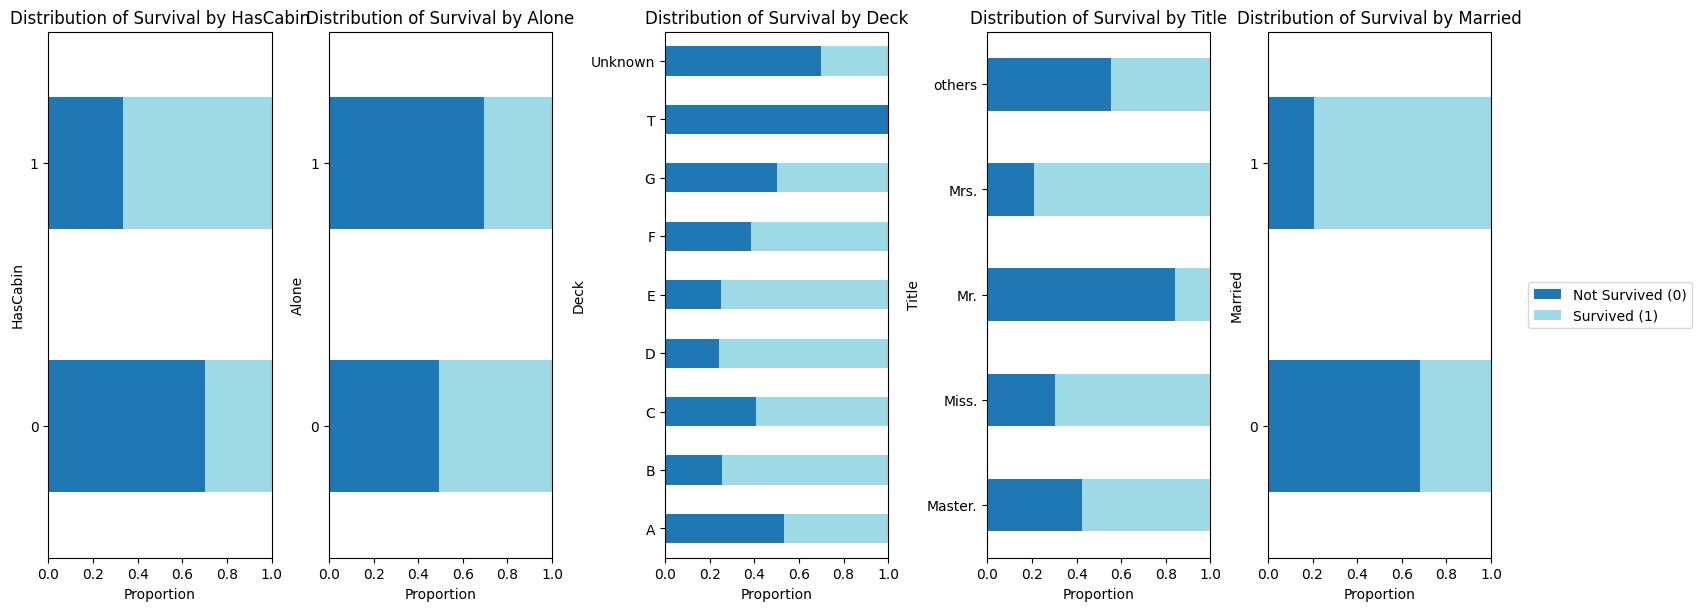

In [102]:
col_list = ['HasCabin', 'Alone', 'Deck', 'Title', 'Married']
plot_survival_distribution(X, col_list, y)

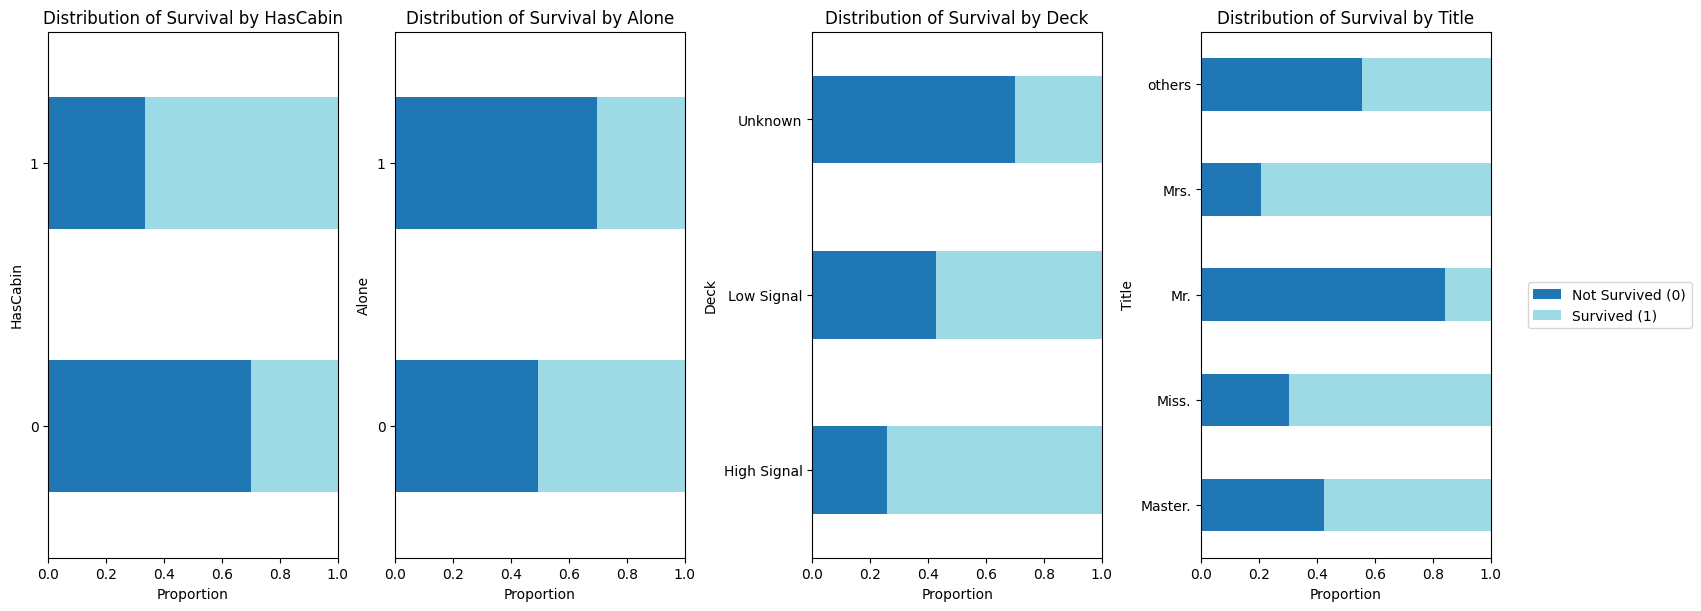

In [103]:
def deck_class(deck):
    if deck=='Unknown':
        return 'Unknown'
    elif deck in ['E', 'D', 'B', 'T']:
        return 'High Signal'
    else:
        return 'Low Signal'
    
X['Deck'] = X['Deck'].apply(deck_class)

col_list = ['HasCabin', 'Alone', 'Deck', 'Title']
plot_survival_distribution(X, col_list, y)


The crosstab analysis with engineered features shows strong signal on the survival rate.

## Data Preprocess

* Columns to drop: `Name`, `Cabin`, `Ticket`
* Boolean columns: `HasCabin`, `Alone`
* Numeral columns to be scaled: `Age`, `Fare`, `SibSp`, `Parch`, `Company`
* Categorical columns: `Sex`, `Pclass`, `Embarked`, `Title`, `Deck`

In [116]:
# create preprocess

num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Company']
cat_cols = ['Sex', 'Pclass', 'Embarked', 'Title', 'Deck']
bol_cols = ['HasCabin', 'Alone']

def create_new_preprocess():
    preprocess = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore')),
            ]), cat_cols),
            ('bol', 'passthrough', bol_cols)
        ],
        remainder='drop'
    )
    return preprocess

In [93]:
preprocess = create_new_preprocess()
X_proc = preprocess.fit_transform(X)
feature_names = preprocess.get_feature_names_out()
X_proc_df = pd.DataFrame(X_proc, columns=feature_names)
X_proc_df.head()


,num__Age,num__Fare,num__SibSp,num__Parch,num__Company,cat__Sex_female,cat__Sex_male,cat__Pclass_1,cat__Pclass_2,cat__Pclass_3,...,cat__Title_Master.,cat__Title_Miss.,cat__Title_Mr.,cat__Title_Mrs.,cat__Title_others,cat__Deck_High Signal,cat__Deck_Low Signal,cat__Deck_Unknown,bol__HasCabin,bol__Alone
0,-0.565736,-0.502445,0.432793,-0.473674,0.059160,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.663861,0.786845,0.432793,-0.473674,0.059160,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.258337,-0.488854,-0.474545,-0.473674,-0.560975,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.433312,0.420730,0.432793,-0.473674,0.059160,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.433312,-0.486337,-0.474545,-0.473674,-0.560975,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


## Baseline Model Training with Engineered Data

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 1 auc score (baseline / dummy): 0.8689 / 0.5000, acc score: 0.7989 / 0.6145
Baseline Model AUC/ACC Mean: 0.8689 ± 0.0000 / 0.7989 ± 0.0000


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 2 auc score (baseline / dummy): 0.8787 / 0.5000, acc score: 0.7978 / 0.6180
Baseline Model AUC/ACC Mean: 0.8738 ± 0.0049 / 0.7983 ± 0.0006


...

Fold 3 auc score (baseline / dummy): 0.8765 / 0.5000, acc score: 0.8202 / 0.6180
Baseline Model AUC/ACC Mean: 0.8747 ± 0.0042 / 0.8056 ± 0.0103


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 4 auc score (baseline / dummy): 0.8362 / 0.5000, acc score: 0.7978 / 0.6180
Baseline Model AUC/ACC Mean: 0.8651 ± 0.0171 / 0.8037 ± 0.0096


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 5 auc score (baseline / dummy): 0.8545 / 0.5000, acc score: 0.8146 / 0.6124
Baseline Model AUC/ACC Mean: 0.8630 ± 0.0158 / 0.8058 ± 0.0096
Dummy Model AUC/ACC Mean: 0.5000 ± 0.0000 / 0.6162 ± 0.0023
Baseline Model AUC/ACC Lift: 0.3630 / 0.1897


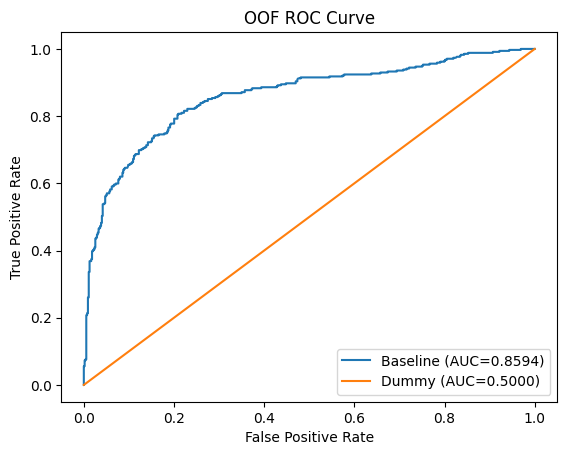

In [117]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=37)
batch_size = 64
epochs = 5
lr = 1e-2
weight_decay=0.0

perform_cv_baseline(X, y, skf, create_new_preprocess, DEVICE, batch_size, epochs, lr, weight_decay);

The first training result shows improvement on accuracy (0.77 to 0.80).

## Baseline Model Optimization

In [120]:
rng = np.random.default_rng(37)
best, history, best_model = random_search(rng, 20, cv_eval_fn)


HPO trials:   0%|          | 0/20 [00:00<?, ?it/s]

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x21 and 12x1)